In [ ]:
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from cdft.dft3d import dft_core

torch.set_default_dtype(torch.float64)
pi = np.pi

plt.rcParams.update({'text.usetex':True, 
'font.family':'sans-serif', 
'font.size':18, 
'axes.linewidth':1.1,
'text.latex.preamble': r'\usepackage{sfmath}'
})

colors = sns.color_palette("mako")

In [2]:
def radial_average(field, r, dr, r_max, weights=None):
    
    nb = int(np.floor(r_max/dr))
    idx = np.floor(r.ravel()/dr).astype(int)
    f = field.ravel()
    m = idx < nb
    idx, f = idx[m], f[m]
    w = np.ones_like(f) if weights is None else weights.ravel()[m]
    num = np.bincount(idx, weights=f*w, minlength=nb)
    den = np.bincount(idx, weights=w, minlength=nb)
    r_c = (np.arange(nb)+0.5)*dr
    out = np.full(nb, np.nan)
    ok = den > 0
    out[ok] = num[ok]/den[ok]
    return r_c, out, den

In [ ]:
sigma, epsilon = 1.0, 1.0
parameters = {'sigma': sigma, 'epsilon': epsilon}
T = 0.75                      
rho_bulk = 0.84
cell_size = np.array([0.04,0.04,0.04])
L = 7.0*sigma
system_size = np.array([L,L,L])
points = np.ceil(system_size/cell_size).astype(int)

dr = float(cell_size[0])

In [4]:
device = torch.device('cuda')
dft = dft_core(parameters, T, system_size, None, points, device)

In [5]:
def lj_potential(r,sigma,epsilon):
    return 4.0*epsilon*((sigma/r)**12-(sigma/r)**6) 

rc = L/2
test_particle = np.array([L/2, L/2, L/2])

Vext = torch.zeros_like(dft.X)
rx = dft.X - test_particle[0]
ry = dft.Y - test_particle[1]
rz = dft.Z - test_particle[2]
rx -= L*(rx/L).round()
ry -= L*(ry/L).round()
rz -= L*(rz/L).round()
r = torch.sqrt(rx**2+ry**2+rz**2)
Vext = lj_potential(r,sigma,epsilon)
Vext[r==0] = np.inf
Vext[r>rc] = 0.0

Text(0, 0.5, '$y$ (\\AA{})')

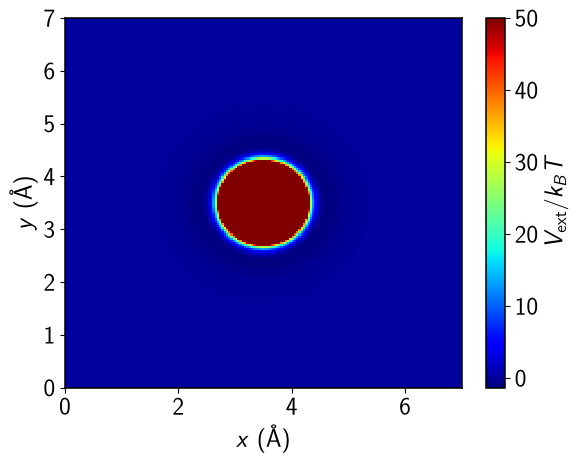

In [6]:
plt.figure()
c=plt.pcolormesh(dft.X[:,:,points[2]//2].cpu(),dft.Y[:,:,points[2]//2].cpu(),Vext[:,:,points[2]//2].cpu()/T,vmax=50.0,cmap='jet')
plt.colorbar(label=r'$V_{\mathrm{ext}}/k_B T$')
plt.xlabel(r'$x$ (\AA{})')
plt.ylabel(r'$y$ (\AA{})')

In [9]:
rho_b = torch.tensor([float(rho_bulk)])
dft.initial_condition(rho_b, Vext, potential_cutoff=50.0, model='bulk')
dft.equilibrium_density_profile(rho_b, fmt='ASWB', solver='anderson', 
                                anderson_mmax=10, anderson_damping=0.2, 
                                tol=1e-8, max_it=2000, logoutput=True)

0 1.2018081869100081
1 1.130826820267321
2 0.9819364616288043
3 1.1657475674789697
4 0.49477697239410584
5 0.29734023150678085
6 0.1824089901755232
7 0.09581350002920218
8 0.04398272136591694
9 0.035854256475483015
10 0.02701796046814984
11 0.026261824812210312
12 0.02419785047715401
13 0.02225506633545493
14 0.022390738819570703
15 0.017006665652871022
16 0.01327277671035543
17 0.014076308607047604
18 0.007525276880793859
19 0.006405086879518371
20 0.005102050552390513
21 0.005345152294518962
22 0.004593619043859291
23 0.004069098989599068
24 0.003297886470539379
25 0.00286694783939257
26 0.0028485882724977015
27 0.0025255102775874234
28 0.002520429427777601
29 0.0022334986837081574
30 0.0019888516051822878
31 0.001561955760932038
32 0.0015818982628507845
33 0.0013850879642838035
34 0.0011354531960301123
35 0.0010625934709173066
36 0.0010572219102317059
37 0.001206707568500541
38 0.0009757749770731104
39 0.0009603447320586884
40 0.000795678134756884
41 0.0007346082805546346
42 0.00063

In [10]:
rho = dft.rho.detach().cpu().numpy()
g3d = rho/float(rho_bulk)
r_c, g, cnt = radial_average(g3d, r.cpu().numpy(), dr, 6.0)

/tmp/ipykernel_116609/1763140456.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=16, frameon=False, edgecolor='k')


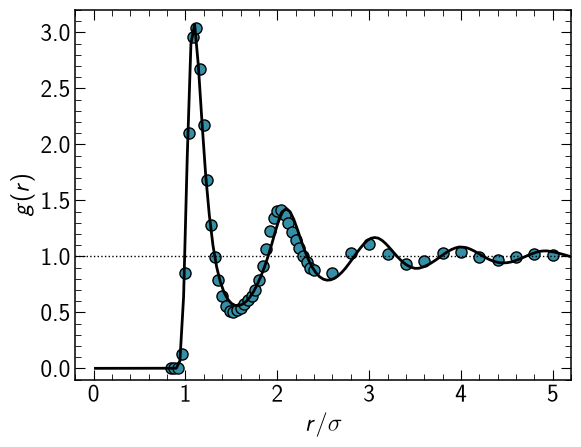

In [11]:
import matplotlib.pyplot as plt

data = np.loadtxt('data/lj-radialdistribution-rho0.84-T0.75.dat', skiprows=1)

plt.plot(data[:,0], data[:,1], 'o', color=colors[3], mew=1.0, ms=8, mec='k')
plt.plot(r_c, g, '-', color='k', lw=2.0)
plt.axhline(1.0, color='k', lw=1.0, ls=':')
plt.xlabel(r'$r/\sigma$', fontsize=18)
plt.ylabel(r'$g(r)$', fontsize=18)
plt.xlim((-0.2,5.2))
plt.ylim((-0.1, 3.2))
plt.minorticks_on()

plt.tick_params(direction='in',right=True, top=True)
plt.tick_params(labelsize=18)
plt.tick_params(labelbottom=True, labeltop=False, labelright=False, labelleft=True)
plt.tick_params(direction='in',which='minor', length=4, bottom=True, top=True, left=True, right=True)
plt.tick_params(direction='in',which='major', length=7, bottom=True, top=True, left=True, right=True)
plt.legend(fontsize=16, frameon=False, edgecolor='k')

Text(0, 0.5, '$y$ (\\AA{})')

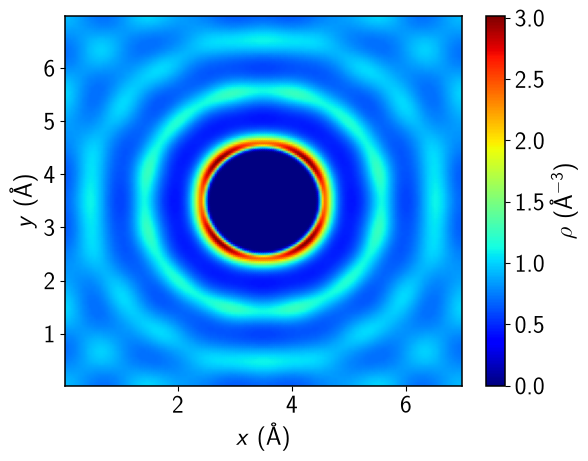

In [13]:
plt.figure()
c=plt.pcolormesh(dft.X[:,:,points[2]//2].cpu(),dft.Y[:,:,points[2]//2].cpu(),dft.rho[:,:,points[2]//2].cpu(),cmap='jet',shading='gouraud')
plt.colorbar(c, label=r'$\rho$ (Å$^{-3}$)')
plt.xlabel(r'$x$ (\AA{})')
plt.ylabel(r'$y$ (\AA{})')

Text(0, 0.5, '$y$ (\\AA{})')

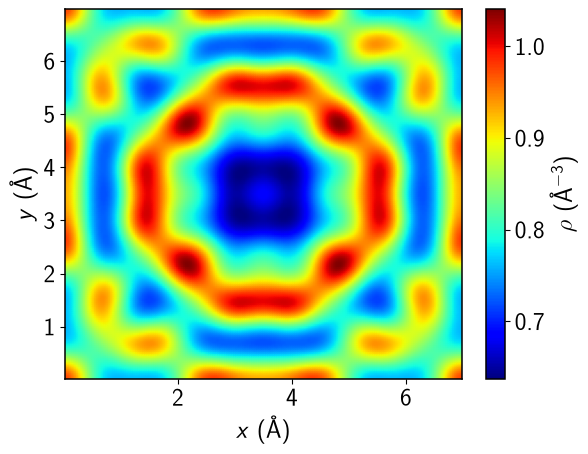

In [14]:
plt.figure()
c=plt.pcolormesh(dft.X[:,:,0].cpu(),dft.Y[:,:,0].cpu(),dft.rho[:,:,0].cpu(),cmap='jet',shading='gouraud')
plt.colorbar(c, label=r'$\rho$ (Å$^{-3}$)')
plt.xlabel(r'$x$ (\AA{})')
plt.ylabel(r'$y$ (\AA{})')